# 11 - PCA Baseline

Linear reconstruction baseline. Fits PCA on nominal training windows
(flattened), scores val + test_intern as window-mean MSE, tunes the
threshold on val (event-wise F0.5), and reports the five standard metrics
on test_intern.

**Inputs**: arrays from `data/processed/` (run `run_preprocessing()`)<br>
**Outputs**: `models/pca.pkl`

Default `sentinel.params.FIT_SIZE = 50_000` <br>
Use `FIT_SIZE=None` to fit on every nominal window


## 0 - Setup & Imports

In [1]:
import sys, json, time, pickle
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.decomposition import PCA

from sentinel.ml_logic.scorer    import score_windows
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import (
    event_f05, corrected_event_f05, row_precision_recall,
)
from sentinel.ml_logic.validation import bootstrap_f05_ci
from sentinel.params import (
    FIT_SIZE, RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR,
)

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

PROCESSED_DIR   = Path('../data/processed')
MODELS_DIR      = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

print(f'FIT_SIZE = {FIT_SIZE!r}   (None = fit on every nominal window)')

FIT_SIZE = 50000   (None = fit on every nominal window)


---
## 1 - Load Preprocessed Arrays

Three-way chronological labelled split written by `run_preprocessing()`:
70 % train / 15 % val / 15 % test_intern. Events do not straddle boundaries
(cuts snapped forward to the nearest nominal row). Scaler fit on nominal
training rows only.

In [2]:
with open(PROCESSED_DIR / 'preprocessing_config.json') as f:
    cfg = json.load(f)

WIN    = cfg['window_size']
N_FEAT = cfg['n_features']
assert WIN == WINDOW_SIZE, f'window mismatch: {WIN} vs {WINDOW_SIZE}'

X_train_nom = np.load(PROCESSED_DIR / 'X_train_nom.npy')

val_scaled  = np.load(PROCESSED_DIR / 'val_scaled.npy')
y_val       = np.load(PROCESSED_DIR / 'y_val.npy')

test_scaled = np.load(PROCESSED_DIR / 'test_intern_scaled.npy')
y_test      = np.load(PROCESSED_DIR / 'y_test_intern.npy')

print(f'X_train_nom      : {X_train_nom.shape}')
print(f'val_scaled       : {val_scaled.shape}   ({int(y_val.sum()):>7,} anom rows)')
print(f'test_intern      : {test_scaled.shape}   ({int(y_test.sum()):>7,} anom rows)')

X_train_nom      : (92271, 100, 58)
val_scaled       : (2232277, 58)   (246,463 anom rows)
test_intern      : (2186220, 58)   (214,961 anom rows)


---
## 2 - Fit PCA on `FIT_SIZE` subsampled windows

Nominal windows are flattened from `(n, WIN, n_feat)` to `(n, WIN*n_feat)` for
PCA. With `FIT_SIZE=None` we fit on every nominal window; with an integer we
take a **random subsample** so the fit is deterministic (seeded) and fast.

`n_components=0.95` keeps 95 % cumulative explained variance. The exact `k`
picked depends on which windows end up in the subsample but is typically
stable within ±2.

In [3]:
X_flat = X_train_nom.reshape(len(X_train_nom), -1).astype(np.float32)
print(f'Nominal training pool: {len(X_flat):,} windows × {X_flat.shape[1]:,} features')

if FIT_SIZE is not None and FIT_SIZE < len(X_flat):
    rng   = np.random.default_rng(RANDOM_STATE)
    idx   = rng.choice(len(X_flat), size=FIT_SIZE, replace=False)
    X_fit = X_flat[idx]
    print(f'Fitting on {len(X_fit):,} subsampled windows (FIT_SIZE={FIT_SIZE:,})')
else:
    X_fit = X_flat
    print(f'Fitting on all {len(X_fit):,} nominal windows (FIT_SIZE=None)')

t0 = time.time()
pca = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(X_fit)
print(f'Fit time: {time.time()-t0:.1f}s')
print(f'n_components kept: {pca.n_components_}   '
      f'(cum EV = {pca.explained_variance_ratio_.sum():.4f})')

Nominal training pool: 92,271 windows × 5,800 features


Fitting on 50,000 subsampled windows (FIT_SIZE=50,000)


Fit time: 59.6s
n_components kept: 38   (cum EV = 0.9501)


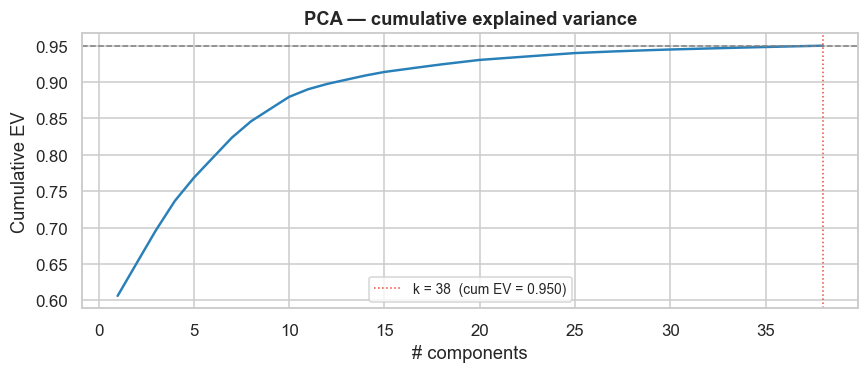

In [ ]:
# Cumulative explained variance - sanity plot
cum_ev = np.cumsum(pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(np.arange(1, len(cum_ev) + 1), cum_ev, lw=1.6, color=NOMINAL_COLOR)
ax.axhline(0.95, ls='--', color='grey', lw=1)
ax.axvline(pca.n_components_, ls=':', color=ANOMALY_COLOR, lw=1,
           label=f'k = {pca.n_components_}  (cum EV = {cum_ev[-1]:.3f})')
ax.set_xlabel('# components')
ax.set_ylabel('Cumulative EV')
ax.set_title('PCA - cumulative explained variance', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

In [11]:
model_path = MODELS_DIR / 'pca.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(pca, f)
print(f'Model saved → {model_path}')

Model saved → ../models/pca.pkl


---
## 3 - Score Val + test_intern

`score_windows` reshapes each row array into non-overlapping windows, runs the
PCA transform+inverse_transform, and broadcasts each window's MSE over its
`WIN` rows. Trailing rows inherit the last window's score.

In [5]:
t0 = time.time()
val_scores  = score_windows(pca, val_scaled,  win=WIN)
print(f'val_scores : {val_scores.shape}   ({time.time()-t0:.1f}s)   '
      f'range [{val_scores.min():.4f}, {val_scores.max():.4f}]')

t0 = time.time()
test_scores = score_windows(pca, test_scaled, win=WIN)
print(f'test_scores: {test_scores.shape}   ({time.time()-t0:.1f}s)   '
      f'range [{test_scores.min():.4f}, {test_scores.max():.4f}]')

val_scores : (2232277,)   (0.8s)   range [0.0175, 664.9958]


test_scores: (2186220,)   (0.6s)   range [0.0258, 3.0895]


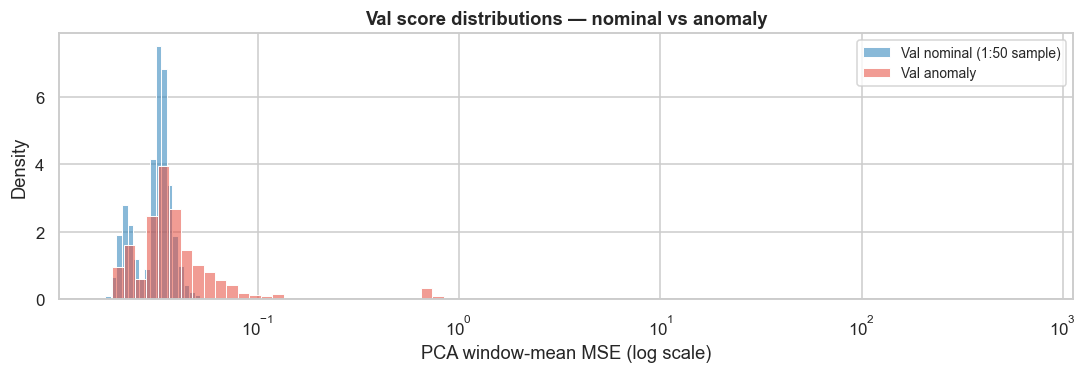

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(val_scores[y_val == 0][::50], ax=ax, color=NOMINAL_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val nominal (1:50 sample)')
sns.histplot(val_scores[y_val == 1], ax=ax, color=ANOMALY_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val anomaly')
ax.set_xlabel('PCA window-mean MSE (log scale)')
ax.set_ylabel('Density')
ax.set_title('Val score distributions - nominal vs anomaly', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 4 - Tune Threshold on Val (event-wise F0.5)

`tune_threshold` sweeps 60 log-spaced candidates between the 50th percentile of
nominal val scores and the 99th percentile of anomaly val scores, evaluates
`event_f05` on each, and returns the argmax. This matches the bootcamp metric
(standard F0.5 - no TNR pull-down).

In [7]:
tune = tune_threshold(val_scores, y_val, metric_fn=event_f05, n_sweep=60)
t_best  = tune['threshold']
val_f05 = tune['score']
print(f'Best threshold: {t_best:.6f}   Val event-F0.5: {val_f05:.4f}')

Best threshold: 0.060404   Val event-F0.5: 0.8333


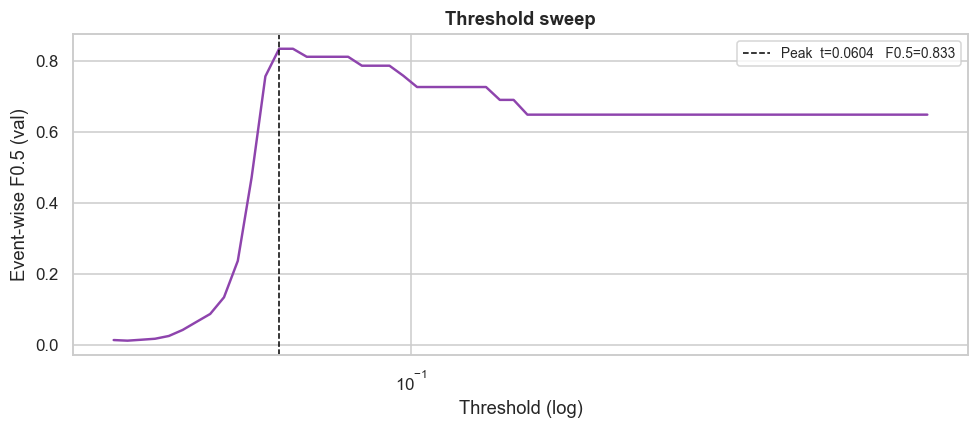

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(tune['sweep_thresholds'], tune['sweep_scores'], lw=1.6, color='#8e44ad')
ax.axvline(t_best, color='black', ls='--', lw=1,
           label=f'Peak  t={t_best:.4f}   F0.5={val_f05:.3f}')
ax.set_xlabel('Threshold (log)')
ax.set_ylabel('Event-wise F0.5 (val)')
ax.set_title('Threshold sweep', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 5 - Evaluate on test_intern

In [9]:
y_pred_test = (test_scores > t_best).astype(np.int8)

ev  = event_f05(y_test, y_pred_test)
esa = corrected_event_f05(y_test, y_pred_test)
rw  = row_precision_recall(y_test, y_pred_test)

metrics = {
    'Event F0.5'        : ev['f_score'],
    'Event recall'      : ev['recall'],
    'Event precision'   : ev['precision'],
    'ESA corrected F0.5': esa['f_score'],
    'Row F1'            : rw['f1'],
}

summary = pd.DataFrame(
    [(k, round(v, 4)) for k, v in metrics.items()],
    columns=['Metric', 'Value'],
)
print(summary.to_string(index=False))

            Metric  Value
        Event F0.5 0.9843
      Event recall 0.9259
   Event precision 1.0000
ESA corrected F0.5 0.4736
            Row F1 0.2281


---
## 6 - Bootstrap CI on test_intern Event-F0.5

Event-block bootstrap: resamples whole events with replacement, drops
predictions inside dropped events (so the CI reflects true event-presence
variance rather than spurious FPs), re-scores. 200 iterations gives a usable
95 % CI.

In [10]:
t0 = time.time()
ci = bootstrap_f05_ci(y_test, y_pred_test, metric_fn=event_f05,
                      n_boot=200, event_block=True, seed=RANDOM_STATE)
print(f'Bootstrap ({time.time()-t0:.1f}s)')
print(f'  mean     : {ci["mean"]:.4f}')
print(f'  std      : {ci["std"]:.4f}')
print(f'  95 % CI  : [{ci["ci_lo_95"]:.4f}, {ci["ci_hi_95"]:.4f}]')

Bootstrap (573.7s)
  mean     : 0.8053
  std      : 0.0770
  95 % CI  : [0.6730, 0.9501]


---
## 8 - Summary

| Item | Value |
|---|---|
| Fit size | `FIT_SIZE` from `sentinel.params` (see §2 print) |
| PCA n_components | see §2 |
| Val event-F0.5 | see §4 |
| test_intern - five-metric table | see §5 |
| 95 % bootstrap CI (event-F0.5) | see §6 |



---
## Summary

**Setup**
- Model: scikit-learn `PCA(n_components=0.95)` on flattened nominal windows (5,800 features each)
- Fit: 50,000 subsampled nominal windows, **59.6 s on CPU**, **k = 38 components** kept (cum EV 0.9501)

**Threshold tuning (val)**
- Best threshold: `0.060404`
- Val event-F0.5 at best threshold: **0.8333**

**Test_intern (5-metric report)**

| Metric | Value |
|---|---:|
| Event F0.5 | **0.9843** |
| Event recall | 0.9259 |
| Event precision | 1.0000 |
| ESA corrected F0.5 | 0.4736 |
| Row F1 | 0.2281 |

**Bootstrap (event-block, aligned truth/pred)**
- Mean event-F0.5: 0.8053 · std 0.0770 · 95 % CI **[0.6730, 0.9501]**
- Wall time: 573.7 s

**Verdict**
- Hits 25 / 27 events with zero spurious event predictions (precision 1.000) → headline event-F0.5 0.984.
- ESA corrected drop (0.984 → 0.474) flags a non-trivial nominal-region alarm density per row.
- Row F1 0.228 reflects window-granularity flagging - only a fraction of flagged rows lie inside the true event extent.
- Wide score dynamic range on val (`[0.018, 665.0]`) gives the threshold sweep a clean separation point. Both AEs (NB 12 / 13) lack this - see their summaries.
